In [3]:
import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

from birdclef_2026_ml.processing.data_split import (
    split_soundscapes_train_val,
    iter_soundscapes_oof_splits
)

from birdclef_2026_ml.processing.memmap_dataset import load_memmap_dataset
from birdclef_2026_ml.notebooks.notebook_utils import init_notebook
from birdclef_2026_ml.training.eval import plot_confusion_matrix, eval_multiclass_singlelabel, safe_multilabel_roc_auc, safe_singlelabel_roc_auc
from birdclef_2026_ml.inference import run_ovr_inference
#from birdclef_2026_ml.feature_engineering.soundscapes import build_soundscape_time_features
from birdclef_2026_ml.models.hierarchical import predict_proba_soft_combination 
from birdclef_2026_ml.models.threshold_tuning import (
    compute_priors_from_labels,
    compute_priors_from_multihot,
    compute_priors_log_odds_from_labels,
    compute_priors_log_odds_from_multihot
)

from sklearn.metrics import balanced_accuracy_score, f1_score, label_ranking_average_precision_score, average_precision_score

from birdclef_2026_ml.paths import load_project_paths
paths = load_project_paths("configs/project.yaml")
from birdclef_2026_ml.models.mil import (
    assign_bag_ids,
    build_bag_feature_matrix
)
from birdclef_2026_ml.inference.mil_inference import run_mil_inference

from pathlib import Path
init_notebook()

In [4]:
path = Path("/Volumes/HDD1TB/BirdCLEF2026/artifacts/models/runs/run_mil/experiments/sgd_baseline")
# class_probas = np.load(path / "inference" / "sgdclassifier_ovr_class_name_probas.npy", allow_pickle=False)
# label_probas = np.load(path / "inference" / "sgdclassifier_ovr_primary_label_probas.npy", allow_pickle=False)

In [12]:
#ss_proba = np.load("/Volumes/HDD1TB/BirdCLEF2026/artifacts/models/runs/run_mil/experiments/sgd_baseline/clean_audio/sgdclassifier_ovr_mil_second_stage_primary_soundscape_proba.npy")
#ss_proba = np.load("/Volumes/HDD1TB/BirdCLEF2026/artifacts/models/runs/run_mil/experiments/sgd_baseline/soundscapes/sgdclassifier_ovr_mil_second_stage_primary_soundscape_context_oof.npy")
ss_proba = np.load("/Volumes/HDD1TB/BirdCLEF2026/artifacts/models/runs/run_chunks_overlap/experiments/sgd_baseline/soundscapes/oof_proba.npy")
ss_true = np.load("/Volumes/HDD1TB/BirdCLEF2026/artifacts/models/runs/run_mil/experiments/sgd_baseline/clean_audio/train_bag_labels_soundscape.npy")
ss_proba

array([[3.13620835e-115, 1.51128814e-004, 6.61237946e-040, ...,
        1.05610512e-001, 1.32781492e-001, 3.63390980e-003],
       [3.70035983e-266, 1.51128814e-004, 3.30695304e-034, ...,
        2.08746240e-001, 2.53865465e-001, 2.23298352e-003],
       [0.00000000e+000, 1.51128814e-004, 1.49544339e-014, ...,
        1.10579875e-001, 9.01676819e-002, 1.07575776e-002],
       ...,
       [0.00000000e+000, 1.24926330e-004, 9.98781125e-001, ...,
        1.49192925e-001, 1.73321617e-001, 8.15521466e-009],
       [0.00000000e+000, 1.60521478e-004, 1.02416146e-020, ...,
        7.99918421e-001, 3.61531509e-002, 8.17802748e-006],
       [0.00000000e+000, 1.60521478e-004, 6.42904980e-009, ...,
        2.88708163e-001, 8.87198125e-002, 1.53386342e-007]],
      shape=(739, 234))

In [13]:
safe_multilabel_roc_auc(ss_true, ss_proba), label_ranking_average_precision_score(ss_true, ss_proba), average_precision_score(ss_true, ss_proba, average="macro")

/Users/bsh2022/Study/master_ue/ml/birdclef_2026_ML/.venv/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/Users/bsh2022/Study/master_ue/ml/birdclef_2026_ML/.venv/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/Users/bsh2022/Study/master_ue/ml/birdclef_2026_ML/.venv/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/Users/bsh2022/Study/master_ue/ml/birdclef_2026_ML/.venv/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/Users/bsh2022/Study/master_ue/ml/birdclef_2026_ML/.venv/lib/python3.13/site-packages/sklearn/me

((0.739801905165794,
  array([       nan, 0.9436851 ,        nan, 0.70768124,        nan,
                nan,        nan,        nan, 0.37148333, 0.70377817,
         0.78138221,        nan,        nan,        nan,        nan,
         0.91568389,        nan,        nan, 0.92036704,        nan,
                nan, 0.89832246,        nan, 0.08596974, 0.87870047,
                nan, 0.98290624,        nan, 0.98762036, 0.46362799,
         0.62399806, 0.08879781, 0.64584943, 0.75537722, 0.67391304,
         0.97919556, 1.        , 0.73166857, 0.09754434, 0.85045927,
         0.85526316, 0.09809264, 0.85316896, 0.08596974, 0.08390646,
         0.08390646, 0.93472668, 0.09422283, 0.95967302, 0.11691884,
         0.9650691 , 0.9708042 , 0.9708042 , 0.99020979, 0.9825518 ,
                nan, 0.99237127, 0.78190013,        nan,        nan,
         0.8726348 ,        nan, 0.64710807, 0.92543159, 0.8622341 ,
         0.97404871, 0.99796472,        nan,        nan, 0.06919946,
             

In [13]:
safe_multilabel_roc_auc(ss_true, ss_proba)[0], label_ranking_average_precision_score(ss_true, ss_proba), average_precision_score(ss_true, ss_proba, average="macro")

/Users/bsh2022/Study/master_ue/ml/birdclef_2026_ML/.venv/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/Users/bsh2022/Study/master_ue/ml/birdclef_2026_ML/.venv/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/Users/bsh2022/Study/master_ue/ml/birdclef_2026_ML/.venv/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/Users/bsh2022/Study/master_ue/ml/birdclef_2026_ML/.venv/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/Users/bsh2022/Study/master_ue/ml/birdclef_2026_ML/.venv/lib/python3.13/site-packages/sklearn/me

(0.6935569403997939, 0.10517649973969719, 0.0855759151983959)

In [65]:
from sklearn.metrics import balanced_accuracy_score, f1_score, label_ranking_average_precision_score

safe_multilabel_roc_auc(ss_true, ss_proba)

(0.4285257749675847,
 array([       nan, 0.87899979,        nan, 0.5       ,        nan,
               nan,        nan,        nan, 0.61008377, 0.53116438,
        0.70642996,        nan,        nan,        nan,        nan,
        0.73653495,        nan,        nan, 0.92763333,        nan,
               nan, 0.61803248,        nan, 0.5       , 0.61282051,
               nan, 0.83968909,        nan, 0.08596974, 0.30460405,
        0.5       , 0.5       , 0.5       , 0.5       , 0.5       ,
        0.5       , 0.5       , 0.5       , 0.5       , 0.5       ,
        0.5       , 0.5       , 0.5       , 0.5       , 0.5       ,
        0.5       , 0.5       , 0.5       , 0.5       , 0.5       ,
        0.5       , 0.5       , 0.5       , 0.5       , 0.5       ,
               nan, 0.37899979, 0.5       ,        nan,        nan,
        0.78879287,        nan, 0.08767123, 0.81838489, 0.54316915,
        0.08767123, 0.08955224,        nan,        nan, 0.08955224,
               nan,        

In [21]:
label_probas = np.load(
    path / "clean_audio/val_proba.npy"
)
label_probas
preds = label_probas.argmax(axis=1)

In [31]:
safe_singlelabel_roc_auc(true, label_probas, classes=np.arange(234))

[[1 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 0 1]]


np.float64(0.847398663405919)

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer, label_binarize

average_precision_score(label_binarize(true, classes=np.arange(234)), label_probas)

/Users/bsh2022/Study/master_ue/ml/birdclef_2026_ML/.venv/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/Users/bsh2022/Study/master_ue/ml/birdclef_2026_ML/.venv/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/Users/bsh2022/Study/master_ue/ml/birdclef_2026_ML/.venv/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/Users/bsh2022/Study/master_ue/ml/birdclef_2026_ML/.venv/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/Users/bsh2022/Study/master_ue/ml/birdclef_2026_ML/.venv/lib/python3.13/site-packages/sklearn/me

0.10205652654633075

<Axes: >

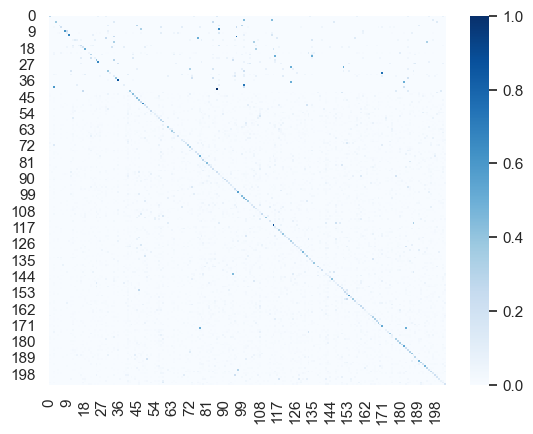

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(true, preds, normalize="true")
sns.heatmap(cm, annot=False, cmap="Blues")
#ConfusionMatrixDisplay(cm).plot()

In [34]:
np.argmax(preds, axis=1)[0]

AxisError: axis 1 is out of bounds for array of dimension 1

In [23]:
true = np.load(path / "clean_audio/val_bag_labels.npy")
true

# from sklearn.preprocessing import MultiLabelBinarizer
# true = MultiLabelBinarizer().fit_transform(true)
# true

array([  0,   0,   0, ..., 233, 233, 233], shape=(40970,), dtype=int32)

In [19]:
type(true)

numpy.ndarray

In [2]:
path = Path("/Volumes/HDD1TB/BirdCLEF2026/artifacts/models/runs/run_mil/experiments/sgd_baseline/clean_audio/train_bag_features.npy")
data=np.load(path)

In [3]:
data

array([[8.09102652e-01, 2.57179819e-03, 9.97987211e-01, ...,
        1.76420233e+00, 1.75275725e+00, 1.69494947e+00],
       [9.76603933e-01, 6.92111292e-05, 9.98634864e-01, ...,
        1.40739601e+00, 1.45040666e+00, 1.32660897e+00],
       [7.69337180e-01, 1.06170158e-01, 9.72306206e-01, ...,
        1.34138536e-01, 2.86966616e-02, 4.28985761e-01],
       ...,
       [3.52689296e-01, 6.68759354e-01, 5.51629105e-01, ...,
        1.60002164e+00, 2.08033473e+00, 1.51804449e+00],
       [5.77489415e-01, 2.46285878e-01, 5.78890888e-01, ...,
        1.27645414e+00, 1.76907391e+00, 1.31167270e+00],
       [1.50860311e-01, 2.31418100e-01, 8.78797484e-01, ...,
        7.25244330e-01, 8.25971560e-01, 1.04830071e+00]],
      shape=(162671, 5676))

In [5]:
mil_res = run_mil_inference(
    "run_mil", 
    "sgd_baseline",
    class_name_proba=class_probas,
    primary_label_proba=label_probas,
    soundscape=False
)

HERE
number of bags 1703399


KeyboardInterrupt: 

In [ ]:
mil_res

In [7]:
val_idx = np.load(path / "val_indices.npy", allow_pickle=False)

In [10]:
dataset = load_memmap_dataset("run_mil", True, False)

<Axes: >

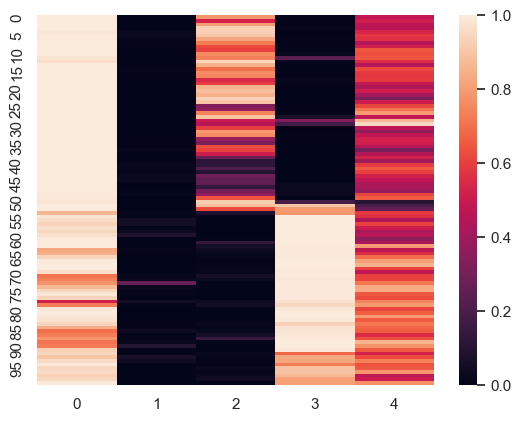

In [20]:
sns.heatmap(class_probas[val_idx[200:300], :5], vmin=0, vmax=1, annot=False)

In [19]:
dataset.y[val_idx[200:300], 0]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [13]:
sns.heatmap(dataset.y[val_idx[:100], 0], vmin=0, vmax=1, annot=False)

IndexError: Inconsistent shape between the condition and the input (got (100, 1) and (100,))

<Axes: >

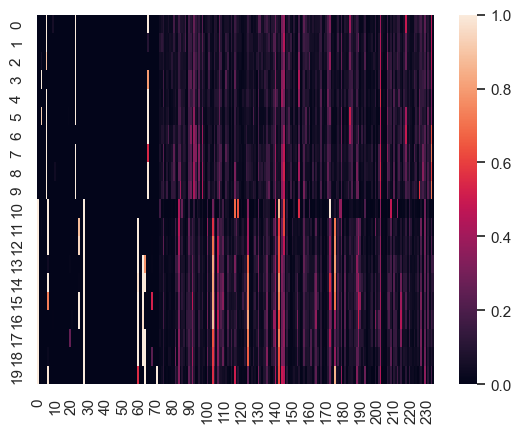

In [6]:
sns.heatmap(label_probas[80:100], vmin=0, vmax=1, annot=False)

In [74]:
dataset = load_memmap_dataset(run_name="run_mil", reduced=True, soundscape=False)
#y_true = dataset_ss.y[:, 1, :]
dataset.bags_meta

array([  0,   1,   2, ..., 189, 190, 191], shape=(1703399,), dtype=int32)

In [82]:
bag_ids = assign_bag_ids(dataset.bags_meta, run_name="run_mil")

windows_per_chunk 9


In [97]:
matrix, y_collapsed = build_bag_feature_matrix(
    np.random.uniform(size=(10000, 5)),
    bag_ids[:10000],
    dataset.y[:10000, 1]
)

In [99]:
matrix

array([[0.44600985, 0.49270278, 0.43084571, ..., 1.91918458, 2.02594929,
        2.15199782],
       [0.50995822, 0.50729403, 0.39690464, ..., 1.90256486, 2.02832787,
        1.96323258],
       [0.38505005, 0.49936056, 0.5672754 , ..., 2.1032745 , 1.85648317,
        1.99933551],
       ...,
       [0.5643435 , 0.40577289, 0.46774689, ..., 2.07897638, 2.05966114,
        2.07552474],
       [0.64360388, 0.65371011, 0.47924274, ..., 2.00606319, 2.11609695,
        1.86457417],
       [0.64407888, 0.48460692, 0.44187347, ..., 1.57344897, 1.72564935,
        1.3240731 ]], shape=(1206, 35))

In [98]:
y_collapsed

array([ 0,  0,  0, ..., 18, 18, 18], shape=(1206,), dtype=int32)

In [83]:
dataset.bags_meta[:50]

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14],
      dtype=int32)

In [84]:
bag_ids[:50]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       5, 5, 5, 5, 5, 5])

In [66]:
path = Path("/Volumes/HDD1TB/BirdCLEF2026/artifacts/models/runs/run_mil/experiments/sgd_baseline/")

artifacts = joblib.load(path / "sgdclassifier_ovr.joblib")
# probas_before = np.load(path / "sgdclassifier_val_probas.npy", allow_pickle=True).item()
# probas_after = np.load(path / "sgdclassifier_val_probas_calibrated_calibration_sigmoid.npy", allow_pickle=True).item()

# preds_before = np.load(path / "sgdclassifier_val_preds.npy", allow_pickle=True).item()
# preds_after = np.load(path / "sgdclassifier_val_preds_calibrated_calibration_sigmoid.npy", allow_pickle=True).item()

dataset = load_memmap_dataset(run_name="run_mil", reduced=True, soundscape=False)
primary_to_class = np.load(paths.primary_to_class / "primary_to_class.npy")

In [29]:
priors = compute_priors_log_odds_from_multihot(
    dataset_ss.y[:, 0, :5],
    dataset_ss.y[:, 1, :],
    primary_to_class,
    k=1
)

In [10]:
priors[0].tolist()

[0.013100319133345098,
 0.9788630239006051,
 0.005877197967356876,
 0.00215048617736875,
 8.972821324208971e-06]

In [31]:
experiment_dir = paths.experiment_dir("run_chunks_overlap", "sgd_baseline")
soundscape_dir = experiment_dir / "soundscapes"
ss_probas_before = np.load(soundscape_dir / "combined_proba.npy")
ss_probas_after = np.load(soundscape_dir / "oof_proba.npy")

In [67]:
dataset = load_memmap_dataset(run_name="run_mil", reduced=True, soundscape=False)
val_idx = np.load("/Volumes/HDD1TB/BirdCLEF2026/artifacts/models/runs/run_mil/experiments/sgd_baseline/val_indices.npy")
artifacts = joblib.load(paths.run_dir("run_mil") / "experiments" / "sgd_baseline" / "sgdclassifier_ovr.joblib")

true_class_name = artifacts.class_name.label_encoder.inverse_transform(dataset.y[val_idx, 0])
true_primary_label = artifacts.primary_label.label_encoder.inverse_transform(dataset.y[val_idx, 1])

In [70]:
dataset.X.shape

(1703399, 590)

In [32]:
dataset_ss = load_memmap_dataset(run_name="run_chunks_overlap", reduced=True, soundscape=True)

In [ ]:
probas_ss, preds_ss = run_ovr_inference(dataset.X[val_idx], artifacts)

<Axes: >

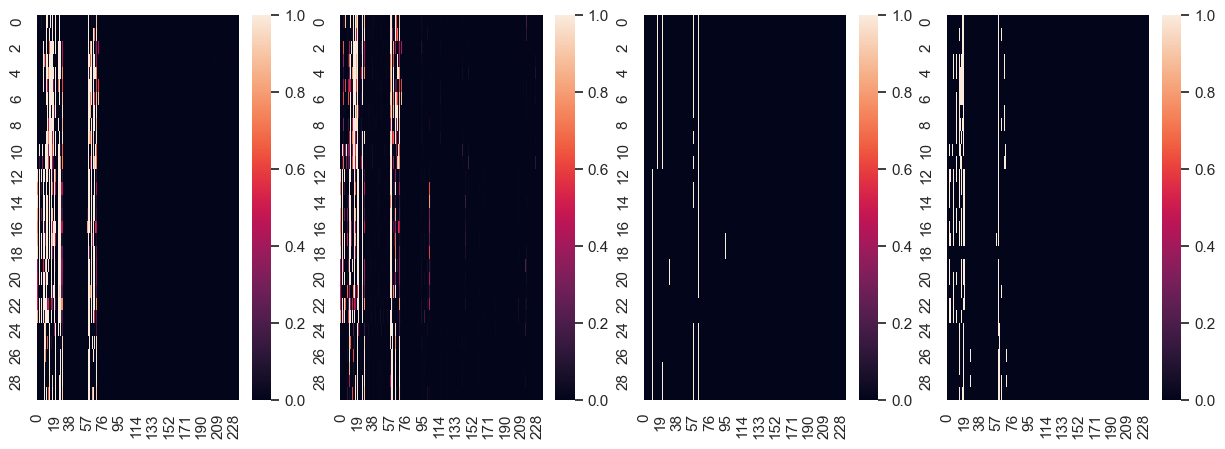

In [56]:
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

priors = compute_priors_log_odds_from_multihot(
    dataset_ss.y[:, 0, :5],
    dataset_ss.y[:, 1, :],
    primary_to_class,
    k=0.001
)

preds_priors = (ss_probas_after > priors[1]).astype(int)
sns.heatmap(ss_probas_before[:30, :], ax=axes[0], annot=False, vmin=0, vmax=1)
sns.heatmap(ss_probas_after[:30, :], ax=axes[1], annot=False, vmin=0, vmax=1)
sns.heatmap(dataset_ss.y[:30, 1, :], ax=axes[2], annot=False)
sns.heatmap(preds_priors[:30, :], ax=axes[3], annot=False)

In [58]:
from sklearn.metrics import f1_score, label_ranking_average_precision_score

print(f1_score(dataset_ss.y[:, 1, :], preds_priors, average="samples", zero_division=0))
print(label_ranking_average_precision_score(dataset_ss.y[:, 1, :], ss_probas_after))

0.22914853694576523
0.30801597050960045


In [59]:
print(label_ranking_average_precision_score(dataset_ss.y[:, 1, :], ss_probas_before))

0.1232109482458006


In [35]:
(ss_probas_after > priors[1]).astype(int)[:, :10]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(739, 10))

In [5]:
# safe_multilabel_roc_auc(dataset_ss.y[:, 1, :], ss_probas_after)[0]

(0.6560544102313954,
 array([       nan, 0.76626404,        nan, 0.76649405,        nan,
               nan,        nan,        nan, 0.47269638, 0.78735086,
        0.90569271,        nan,        nan,        nan,        nan,
        0.90674772,        nan,        nan, 0.87929696,        nan,
               nan, 0.92885854,        nan, 0.05318661, 0.58531469,
               nan, 0.85839203,        nan, 0.99530032, 0.81482505,
        0.70342482, 0.10031226, 0.26221135, 0.89929933, 0.40398551,
        0.96432424, 0.9998191 , 0.30853837, 0.10754889, 0.24800412,
        0.56962225, 0.10354223, 0.72166904, 0.09731774, 0.13927098,
        0.13927098, 0.96317829, 0.12070151, 0.87983651, 0.08791839,
        0.99816153, 0.99982517, 0.99982517, 0.94143357, 0.85292621,
               nan, 0.89489299, 0.83985061,        nan,        nan,
        0.90468089,        nan, 0.67960426, 0.90179588, 0.88843135,
        0.81019787, 0.96743555,        nan,        nan, 0.05359566,
               nan,        

In [61]:
safe_multilabel_roc_auc(dataset_ss.y[:, 1, :], probas_ss["primary_label"])

(0.5714013905657648,
 array([       nan, 0.5       ,        nan, 0.5       ,        nan,
               nan,        nan,        nan, 0.4508851 , 0.75738511,
        0.68219711,        nan,        nan,        nan,        nan,
        0.61054205,        nan,        nan, 0.88655814,        nan,
               nan, 0.50364526,        nan, 0.5       , 0.36652098,
               nan, 0.70187637,        nan, 0.90371389, 0.6160221 ,
        0.5       , 0.5       , 0.5       , 0.5       , 0.5       ,
        0.5       , 0.5       , 0.5       , 0.5       , 0.5       ,
        0.5       , 0.5       , 0.5       , 0.5       , 0.5       ,
        0.5       , 0.5       , 0.5       , 0.5       , 0.5       ,
        0.5       , 0.5       , 0.5       , 0.5       , 0.5       ,
               nan, 0.84901462, 0.5       ,        nan,        nan,
        0.70622918,        nan, 0.64855403, 0.61894777, 0.42925151,
        0.71925419, 0.85820896,        nan,        nan, 0.33717775,
               nan,        

In [18]:
artifacts_calibrated = joblib.load(path / "sgdclassifier_ovr_calibrated_calibration_sigmoid.joblib")

In [21]:
probas_soft = predict_proba_soft_combination(
    artifacts_class_name=artifacts.class_name,
    artifacts_primary_label=artifacts.primary_label,
    x=dataset_ss.X,
    y_class_name=np.load(paths.primary_to_class / "primary_to_class.npy")
)

In [63]:
from sklearn.metrics import f1_score, precision_score, recall_score
safe_multilabel_roc_auc(dataset_ss.y[:, 1, :], (probas_ss["primary_label"] > 0.5).astype(int), average="macro"), safe_multilabel_roc_auc(dataset_ss.y[:, 1, :],probas_soft)[0]

Failed to reload module 'birdclef_2026_ml.training.eval' from file '/Users/bsh2022/Study/master_ue/ml/birdclef_2026_ML/src/birdclef_2026_ml/training/eval.py'
Traceback (most recent call last):
  File "/Users/bsh2022/Study/master_ue/ml/birdclef_2026_ML/.venv/lib/python3.13/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/bsh2022/Study/master_ue/ml/birdclef_2026_ML/.venv/lib/python3.13/site-packages/IPython/extensions/autoreload.py", line 584, in superreload
    module = reload(module)
  File "/Users/bsh2022/.local/share/uv/python/cpython-3.13.11-macos-aarch64-none/lib/python3.13/importlib/__init__.py", line 129, in reload
    _bootstrap._exec(spec, module)
    ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 866, in _exec
  File "<frozen importlib._bootstrap_external>", line 1019, in exec_module
  File "<frozen importlib._bootstrap_extern

KeyboardInterrupt: 

In [23]:
preds_priors = (probas_before["class_name"] > priors[0]).astype(int)
eval_multiclass_singlelabel(
    true_class_name,
    preds_priors,
    probas_before["class_name"],
    classes=artifacts.class_name.label_encoder.classes_,
    target_name="class_name",
    approach="OVR class_name"
)
plot_confusion_matrix(true_class_name, preds_priors, normalize="true", annot=True)

ValueError: Classification metrics can't handle a mix of multiclass and multilabel-indicator targets

/Users/bsh2022/Study/master_ue/ml/birdclef_2026_ML/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")



===== class_name | OVR class_name =====
n_samples=67296
accuracy=0.9529
balanced_accuracy=0.5076
top2_accuracy=0.9740
top3_accuracy=0.9900
macro_precision=0.3509
macro_recall=0.4061
macro_f1=0.3726
macro_roc_auc=0.9245


<Axes: title={'center': 'Normalized Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>

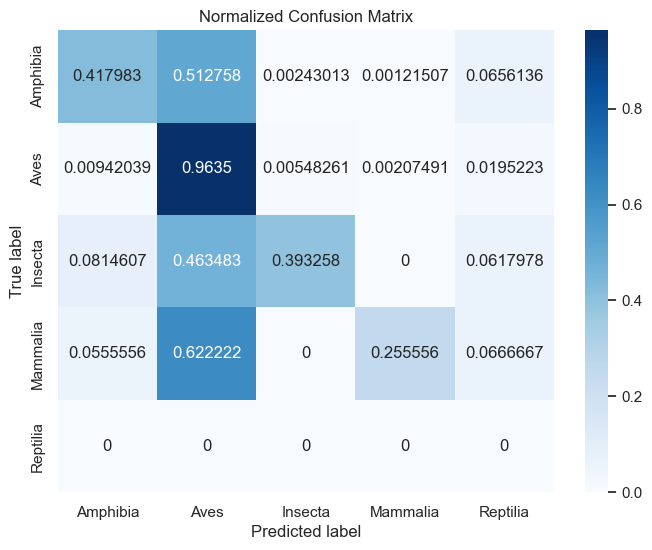

In [139]:
eval_multiclass_singlelabel(
    true_class_name,
    preds_after["class_name"],
    probas_after["class_name"],
    classes=artifacts.class_name.label_encoder.classes_,
    target_name="class_name",
    approach="OVR class_name"
)
plot_confusion_matrix(true_class_name, preds_after["class_name"], normalize="true", annot=True)

/Users/bsh2022/Study/master_ue/ml/birdclef_2026_ML/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")



===== primary_label | OVR primary_label =====
n_samples=67296
accuracy=0.0038
balanced_accuracy=0.0284
top2_accuracy=0.0041
top3_accuracy=0.0063
macro_precision=0.0020
macro_recall=0.0277
macro_f1=0.0036
macro_roc_auc=0.8274


<Axes: title={'center': 'Normalized Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>

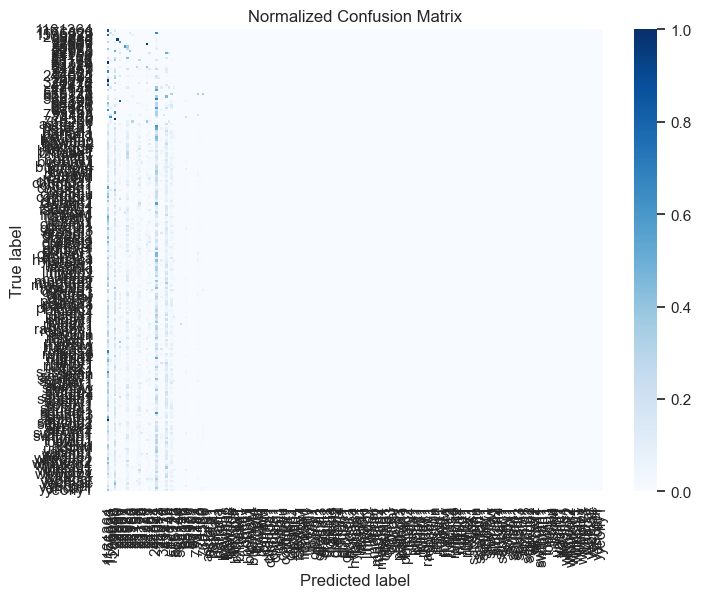

In [141]:
eval_multiclass_singlelabel(
    true_primary_label,
    preds_before["primary_label"],
    probas_before["primary_label"],
    classes=artifacts.primary_label.label_encoder.classes_,
    target_name="primary_label",
    approach="OVR primary_label"
)
plot_confusion_matrix(true_primary_label, preds_before["primary_label"], normalize="true", annot=False)

/Users/bsh2022/Study/master_ue/ml/birdclef_2026_ML/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")



===== primary_label | OVR primary_label =====
n_samples=67296
accuracy=0.0044
balanced_accuracy=0.0323
top2_accuracy=0.0044
top3_accuracy=0.0068
macro_precision=0.0016
macro_recall=0.0316
macro_f1=0.0030
macro_roc_auc=0.8278


<Axes: title={'center': 'Normalized Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>

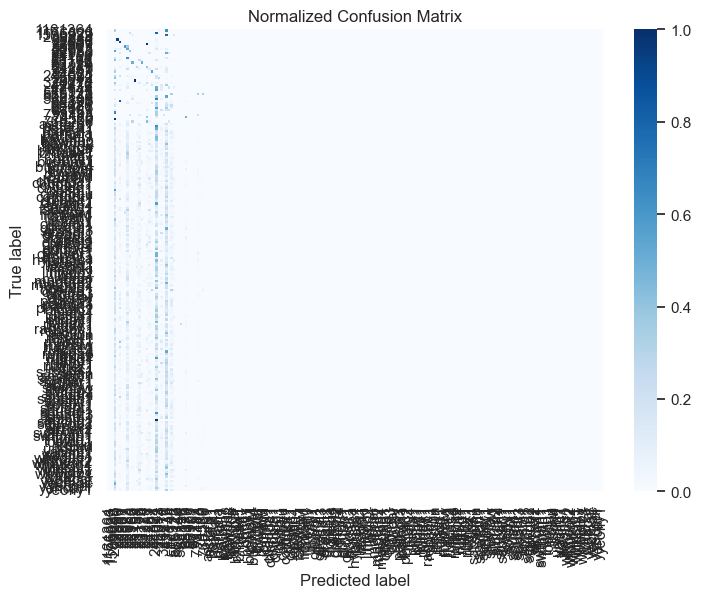

In [142]:
eval_multiclass_singlelabel(
    true_primary_label,
    preds_after["primary_label"],
    probas_after["primary_label"],
    classes=artifacts.primary_label.label_encoder.classes_,
    target_name="primary_label",
    approach="OVR primary_label"
)
plot_confusion_matrix(true_primary_label, preds_after["primary_label"], normalize="true", annot=False)